In [20]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import argparse
import csv
import fcntl
import jax
import math
import jax.numpy as jnp
import optax
import flax
from flax import nnx
from flax.nnx.nn import initializers
from typing import Callable
import json
import glob

import pickle
import numpy as np
from collections import defaultdict
from functools import partial
from tqdm import tqdm
from datetime import date

from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.animation as animation
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris
import cmap



from utils import ternary_activation, load_cifar10_augment, dual_sample_ternary, load_uci_iris
from models import TernaryStochasticActivation, DualSampleTernary, CustomLinear, FFN 

import tensorflow_datasets as tfds  # TFDS to download CIFAR-10.
import tensorflow as tf  # TensorFlow / `tf.data` operations.
tf.config.set_visible_devices([], 'GPU')




today = date.today().isoformat()

In [2]:
# set the flag for stayem
system_flag = "macbook" # or mahowald

# Path for loading the models: UPDATE BASED ON MACHINE
if system_flag == "mahowald":
    MODEL_PATH = "/local_disk/vikrant/trident/models"
    FIGURES_PATH = "../plots/"
    DATA_PATH = "/local_disk/vikrant/trident/logs"

elif system_flag == "macbook":
    # set latex backend for matplotlib
    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amssymb}'
    
    DATA_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs"
    MODEL_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/models"
    FIGURES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels"
    SLIDES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/presentation_figures"


else:
    raise ValueError("Invalid system flag. Please set it to either 'mahowald' or 'macbook'.")

print("*** PATHS ARE SET AS ***")
print(f"Model path: {MODEL_PATH}")
print(f"Data path: {DATA_PATH}")
print(f"Figures path: {FIGURES_PATH}")

*** PATHS ARE SET AS ***
Model path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/models
Data path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs
Figures path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels


In [ ]:
# clean up functions
def _dedup_inset(df: pd.DataFrame) -> pd.DataFrame:
    """F1: one row per (num_classes, resample) for window-independent metrics."""
    return df.drop_duplicates(subset=["num_classes", "resample"])


def _one_sf(df: pd.DataFrame) -> pd.DataFrame:
    """F2: cosine is scale-invariant -> keep a single scale_factor."""
    if "scale_factor" not in df.columns:
        return df
    sf = 1.0 if np.any(np.isclose(df["scale_factor"], 1.0)) else df["scale_factor"].min()
    return df[np.isclose(df["scale_factor"], sf)]


def measured_slope(df: pd.DataFrame) -> float:
    """F4: slope of the norm scatter = ||target|| / ||estimator_infty||.
    nu and scale_factor both cancel, so this is purely the link gap."""
    d = _one_sf(df)
    return float((d["norm_ratio_z_q"] / d["norm_ratio_z_s"]).mean())

In [4]:
# load the softmax data // GAUSSIAN
softmax_payload = pickle.load(open(os.path.join(DATA_PATH, "softmax_mc_analysis_gauss_2026-08-17.pkl"), "rb"))
softmax_data = softmax_payload['data']
print(f"SOFTMAX CONFIGS: {softmax_payload['configs']}")
softmax_data = pd.DataFrame(softmax_data)
softmax_data["sf_opt"] = softmax_data["norm_ratio_z_s"]/softmax_data["norm_ratio_z_q"]
print(softmax_data.head())

# load the softmax-jacobian data
softmax_jac_payload = pickle.load(open(os.path.join(DATA_PATH, "softmax_jacobian_mc_analysis_gauss_2026-08-17.pkl"), "rb"))
softmax_jac_data = softmax_jac_payload['data']
print(f"SOFTMAX JACOBIAN CONFIGS: {softmax_jac_payload['configs']}")

softmax_jac_data = pd.DataFrame(softmax_jac_data)
softmax_jac_data["sf_opt"] = softmax_jac_data["scale_factor"]*(1/softmax_jac_data["norm_ratio_z_q"])
print(softmax_jac_data.head())


# Loading data // Logistic
softmax_log_payload = pickle.load(open(os.path.join(DATA_PATH, "softmax_mc_analysis_logistic_2026-08-29.pkl"), "rb"))
softmax_log_data = softmax_log_payload["data"]
print(f"SOFTMAX LOG CONFIGS: {softmax_log_payload["configs"]}")
softmax_log_data = pd.DataFrame(softmax_log_data)

softmax_log_jac_payload = pickle.load(open(os.path.join(DATA_PATH, "softmax_jacobian_mc_analysis_logistic_2026-08-29.pkl"), "rb"))
softmax_log_jac_data = softmax_log_jac_payload["data"]
print(f"SOFTMAX LOG CONFIGS: {softmax_log_jac_payload["configs"]}")
softmax_log_jac_data = pd.DataFrame(softmax_log_jac_data)

print(f"SOFTMAX LOGISTIC: \n {softmax_log_data.head()}")
print(f"SOFTMAX LOGISTIC JACOBIAN: \n {softmax_log_jac_data.head()}")



SOFTMAX CONFIGS: {'resamples': 30, 'num_classes': [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], 'preact_scale': 1.0, 'noise_scale': 1.0}
   cos_sim_z_s  cos_sim_z_q  cos_sim_q_s  norm_ratio_z_s  norm_ratio_z_q  \
0     0.923279     0.939999     0.998938        1.307410        1.281176   
1     0.997372     0.999651     0.998938        1.033598        1.012859   
2     0.968323     0.978801     0.998938        1.155598        1.132411   
3     0.968323     0.978801     0.998938        1.155598        1.132411   
4     0.977789     0.986409     0.998938        1.121882        1.099372   

   num_classes  int_window  resample    sf_opt  
0            2           2         0  1.020476  
1            2           4         0  1.020476  
2            2           8         0  1.020476  
3            2          16         0  1.020476  
4            2          32         0  1.020476  
SOFTMAX JACOBIAN CONFIGS: {'resamples': 30, 'num_classes': [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], 'preact_sca

## Gaussian softmax + jacobian

<>:27: SyntaxWarning: invalid escape sequence '\#'
<>:27: SyntaxWarning: invalid escape sequence '\#'
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_25704/577597215.py:27: SyntaxWarning: invalid escape sequence '\#'
  axl_inset.set_xlabel("\# Classes", fontsize=14)


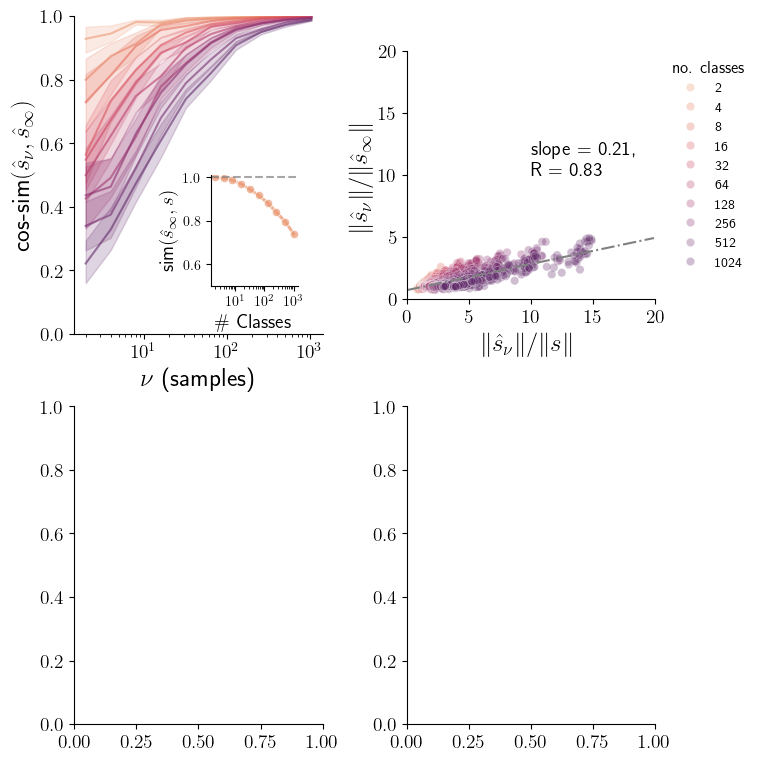

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(7.5, 7.5), layout="constrained")

# top panels: softmax
flare_pal_sf = sns.color_palette("flare", len(softmax_data['num_classes'].unique()))
flare_pal_jac = sns.color_palette("flare", len(softmax_data['num_classes'].unique()))

# for guides
x = jnp.arange(0, 20, 0.1)


sns.lineplot(data=softmax_data, x="int_window", y="cos_sim_z_q", hue="num_classes", lw=1.5, alpha=0.6, ax=ax[0,0], palette=flare_pal_sf)
ax[0,0].set_xscale("log", base=10) 
ax[0,0].set_ylabel(r"$\text{cos-sim}(\hat{s}_\nu, \hat{s}_\infty)$", fontsize=18)
ax[0,0].legend().set_visible(False)
ax[0,0].set_xlabel(r"$\nu$ (samples)", fontsize=18)
ax[0,0].set_ylim(0, 1)

# add the inset axis

## drop duplicates for q vs s
gauss_cos_sim = softmax_data.drop_duplicates(subset=["num_classes", "resample"])
axl_inset = ax[0,0].inset_axes([0.55, 0.15, 0.35, 0.35])
sns.lineplot(data=gauss_cos_sim, x="num_classes", y="cos_sim_q_s", ax=axl_inset, alpha=0.7, color=flare_pal_sf[0], lw=2, marker="o")
axl_inset.set_xscale("log", base=10)
axl_inset.axhline(y=1.0, color="0.5", alpha=0.7, lw=1.5, ls="--")
axl_inset.set_ylabel(r"$\text{sim}(\hat{s}_\infty, s)$", fontsize=14)
axl_inset.set_xlabel("\# Classes", fontsize=14)
axl_inset.set_ylim(0.5, 1.01)
sns.despine(ax=axl_inset)

## norm comparison: z vs s

# regression fit
reg_ = linregress(softmax_data["norm_ratio_z_s"].to_numpy(), softmax_data["norm_ratio_z_q"].to_numpy())
sns.scatterplot(data=softmax_data, x="norm_ratio_z_s", y="norm_ratio_z_q", hue="num_classes", palette=flare_pal_sf, ax=ax[0,1], alpha=0.3)
ax[0,1].set_ylabel(r"$\lVert \hat{s}_\nu \rVert / \lVert \hat{s}_\infty \rVert$", fontsize=18)
ax[0,1].set_xlabel(r"$\lVert \hat{s}_\nu \rVert / \lVert s \rVert$", fontsize=18)
ax[0,1].legend(frameon=False, title="no. classes", title_fontsize=12, loc=(1.05, 0.1))
# ax[0,1].plot(x, x, color="0.5", lw=1.5, ls="--")
ax[0,1].plot(x, x*reg_.slope + reg_.intercept, color="0.5", lw=1.5, ls="-.")
ax[0, 1].text(10, 10, f"slope = {reg_.slope:.02f},\nR = {reg_.rvalue:.02f}", fontsize=14)
ax[0,1].set_aspect("equal")
ax[0,1].set_xlim(0, 20)
ax[0,1].set_ylim(0, 20)


## Bottom: Jacobian

# x = jnp.arange(0, 30, 0.1)
# for axs in ax.ravel():
#     axs.set_xscale("log", base=2)

flare_pal_jac = sns.color_palette("flare", len(softmax_jac_data['num_classes'].unique()))
# crest_pal = sns.color_palette("crest", len(softmax_data['num_classes'].unique()))
# cb_pal = sns.color_palette("colorblind", len(softmax_data['num_classes'].unique()))

## z and q (q vs s inset)
sns.lineplot(data=softmax_jac_data, x="int_window", y="cos_sim_z_q", hue="num_classes", lw=1.5, alpha=0.6, ax=ax[1,0], palette=flare_pal_jac)
ax[0].set_xscale("log", base=10) 
ax[0].set_ylabel(r"$\text{cos-sim}(\hat{J}_\nu, \hat{J}_\infty)$", fontsize=18)
ax[0].legend().set_visible(False)
ax[0].set_xlabel(r"$\nu$ (samples)", fontsize=18)

# add the inset axis
axl_inset = ax[0].inset_axes([0.65, 0.2, 0.35, 0.35])
sns.lineplot(data=softmax_jac_data, x="num_classes", y="cos_sim_q_s", ax=axl_inset, alpha=0.7, color=flare_pal[0], lw=2, marker="o")
axl_inset.set_xscale("log", base=10)
axl_inset.axhline(y=1.0, color="0.5", alpha=0.7, lw=1.5, ls="--")
axl_inset.set_ylabel(r"$\text{sim}(\hat{J}_\infty, J)$", fontsize=14)
axl_inset.set_xlabel("\# Classes", fontsize=14)
axl_inset.set_ylim(0.5, 1.01)

## norm comparison: z vs s
df_c = softmax_jac_data.loc[softmax_jac_data['scale_factor'] == 1.0]
sns.scatterplot(data=df_c, x="norm_ratio_z_s", y="norm_ratio_z_q", hue="num_classes", palette=flare_pal, ax=ax[1], alpha=0.3)
ax[1].set_ylabel(r"$\lVert \hat{J}_\nu \rVert / \lVert \hat{J}_\infty \rVert$", fontsize=18)
ax[1].set_xlabel(r"$\lVert \hat{J}_\nu \rVert / \lVert J \rVert$", fontsize=18)
ax[1].legend(frameon=False, title="no. classes", title_fontsize=12, loc=(1.05, 0.1))
ax[1].plot(x, x, color="0.5", lw=1.5, ls="--")
ax[1].plot(x, x/3, color="0.5", lw=1.5, ls="-.")
ax[1].set_aspect("equal")
ax[1].set_xlim(0, 20)
ax[1].set_ylim(0, 20)



for axs in ax.ravel():
    axs.tick_params(axis='both', which='major', labelsize=14)

    

sns.despine()

# softmax_gauss_fn2 = f"softmax_gauss_mc_{today}.png"
# fig.savefig(os.path.join(FIGURES_PATH, softmax_gauss_fn2), transparent=True, dpi=300, bbox_inches="tight")


In [28]:
# try out regress
reg_ = linregress(softmax_data["norm_ratio_z_s"].to_numpy(), softmax_data["norm_ratio_z_q"].to_numpy())
print(reg_)

LinregressResult(slope=np.float64(0.21086964408276657), intercept=np.float64(0.7218683379316995), rvalue=np.float64(0.8348631607034117), pvalue=np.float64(0.0), stderr=np.float64(0.0025392576974589544), intercept_stderr=np.float64(0.008825412469855309))
